# Классическое машинное обучение
### Линейная алгебра в машинном обучении.

In [ ]:
import numpy as np
import scipy as sp

In [ ]:
dir(np.linalg)

['LinAlgError',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_linalg',
 '_umath_linalg',
 'cholesky',
 'cond',
 'cross',
 'det',
 'diagonal',
 'eig',
 'eigh',
 'eigvals',
 'eigvalsh',
 'inv',
 'linalg',
 'lstsq',
 'matmul',
 'matrix_norm',
 'matrix_power',
 'matrix_rank',
 'matrix_transpose',
 'multi_dot',
 'norm',
 'outer',
 'pinv',
 'qr',
 'slogdet',
 'solve',
 'svd',
 'svdvals',
 'tensordot',
 'tensorinv',
 'tensorsolve',
 'test',
 'trace',
 'vecdot',
 'vector_norm']

### Задача 1

Напишите функцию, которая находит Евклидово расстояние между двумя точками. В этом задании напишите формулу вручную, без явного использования циклов (используйте векторизацию).

In [ ]:
def distance(x: np.array, y: np.array) -> float:
  # Вычисляем разность векторов поэлементно (векторизованная операция)
    diff = x - y

    # Возводим каждый элемент в квадрат, суммируем и извлекаем квадратный корень
    squared_diff = diff ** 2
    sum_squared = np.sum(squared_diff)
    euclidean_distance = np.sqrt(sum_squared)

    return euclidean_distance

In [ ]:
def distance(x: np.array, y: np.array) -> float:
    return np.sqrt(np.sum((x - y) ** 2))

In [ ]:
# Do not change the tests!
# They are for your convenience.
x = np.array([1, 2, 3])
y = np.array([3, 4, 5])
np.testing.assert_almost_equal(
    actual=distance(x, y),
    desired=np.linalg.norm(x - y)
)
x = np.random.normal(size=100)
y = np.random.normal(size=100)
np.testing.assert_almost_equal(
    actual=distance(x, y),
    desired=np.linalg.norm(x - y)
)

### Задача 2

Как с помощью скалярного произведения найти угол между векторами?

Напишите функцию, принимающую на вход 2 вектора и возвращающую угол между этими векторами (в радианах)

In [ ]:
def angle_between_vectors(u: np.array, v: np.array) -> float:
    dot_product = np.dot(u, v) #скалярное произведение (можно через @)
    norms_product = np.linalg.norm(u) * np.linalg.norm(v)

    # Защита от деления на ноль и погрешностей
    if norms_product == 0:
        return 0.0  # или np.nan, в зависимости от требований

    cos_theta = dot_product / norms_product
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # Численная стабильность

    return np.arccos(cos_theta)

In [ ]:
# Do not change the tests!
# They are for your convenience.
u = np.array([1, 2, 3])
v = np.array([1, 1, -1])
np.testing.assert_almost_equal(
    actual=angle_between_vectors(u, v),
    desired=np.deg2rad(90.0),
    err_msg='Test 1 failed'
)

deg = np.deg2rad(45.0)
u = np.array([1, 3])
v = np.array([[np.cos(deg), np.sin(deg)], [-np.sin(deg), np.cos(deg)]]) @ u  #матрица поворота
np.testing.assert_almost_equal(
    actual=angle_between_vectors(u, v),
    desired=deg,
    err_msg='Test 2 failed'
)

u = np.random.normal(size=100)
v = np.random.normal(size=100)
v[-1] = -(u[:-1] @ v[:-1]) / u[-1]
np.testing.assert_almost_equal(
    actual=angle_between_vectors(u, v),
    desired=np.deg2rad(90.0),
    err_msg='Test 3 failed (might rarely fail stochastically)'
)

### Задача 3

Сгенерируйте 100 случайных 1000-мерных векторов из стандартного нормального распределения (т.е. матрицу из $\mathbb{R}^{1000\times 100}$)

Векторизованно вычислите углы между всеми парами векторов (для удобства преобразуйте их в градусы). Постройте гистограмму полученных углов с помощью функции `plt.hist(angles, bins=50)`.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
A = np.random.normal(1000,100)

In [ ]:
np.random.seed(42)

# Генерируем 100 случайных 1000-мерных векторов
# Матрица размером (1000, 100) - 1000 строк (размерность), 100 столбцов (векторы)
A = np.random.normal(size=(1000, 100))

# Нормализуем все векторы одной операцией
# np.linalg.norm с axis=0 вычисляет норму для каждого столбца
norms = np.linalg.norm(A, axis=0, keepdims=True)  # форма (1, 100)
A_normalized = A / norms  # broadcasting: каждый столбец делится на свою норму

# Вычисляем все попарные скалярные произведения (матрица косинусов)
# Транспонируем A_normalized: (100, 1000) @ (1000, 100) = (100, 100)
cosine_matrix = A_normalized.T @ A_normalized  # полная матрица попарных косинусов

# Извлекаем верхний треугольник без диагонали
# np.triu_indices возвращает индексы элементов выше главной диагонали
i, j = np.triu_indices(100, k=1)
cosine_values = cosine_matrix[i, j]

# Защита от погрешностей вычислений
cosine_values = np.clip(cosine_values, -1.0, 1.0)

# Преобразуем все косинусы в углы одной операцией
angles_rad = np.arccos(cosine_values)
angles_deg = np.degrees(angles_rad)

In [ ]:
# np.random.seed(42)  # для генереции одних и тех же числел(для сходимости результатов)
A = np.random.normal(size=(1000,100))
norms = np.linalg.norm(A)
cos_angles = (A.T @ A) / np.outer(norms, norms)
angles = np.acos(cos_angles)
#angles = angles[np.triu_indices_from(A, k=1)]

In [ ]:
#другой вариант
angles = angles[~np.eye(A.shape[1], dtype=bool)]

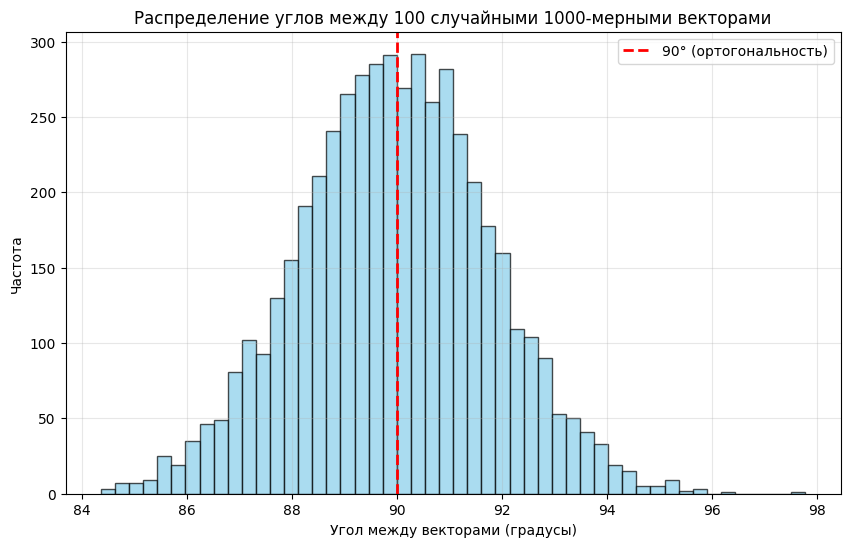

Средний угол: 89.95°
Медианный угол: 89.95°
Стандартное отклонение: 1.81°


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(angles_deg, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Угол между векторами (градусы)')
plt.ylabel('Частота')
plt.title('Распределение углов между 100 случайными 1000-мерными векторами')
plt.grid(True, alpha=0.3)
plt.axvline(x=90, color='red', linestyle='--', linewidth=2, label='90° (ортогональность)')
plt.legend()
plt.show()

# Выводим базовую статистику (тоже векторизованно)
print(f"Средний угол: {np.mean(angles_deg):.2f}°")
print(f"Медианный угол: {np.median(angles_deg):.2f}°")
print(f"Стандартное отклонение: {np.std(angles_deg):.2f}°")

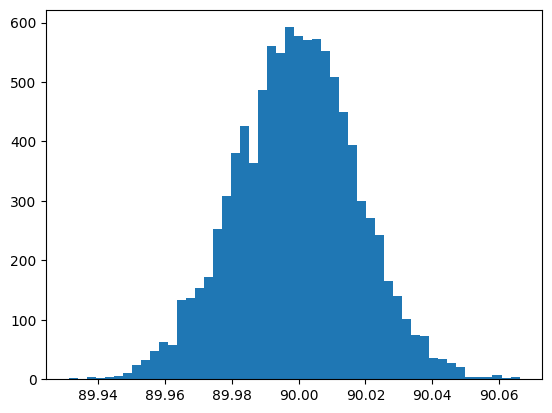

In [ ]:
plt.hist(np.rad2deg(angles), bins=50)
plt.show()

/tmp/ipython-input-3140632191.py:3: RuntimeWarning: invalid value encountered in arccos
  angles = np.rad2deg(np.arccos((X.T @ X) / norm_X / norm_X.T))


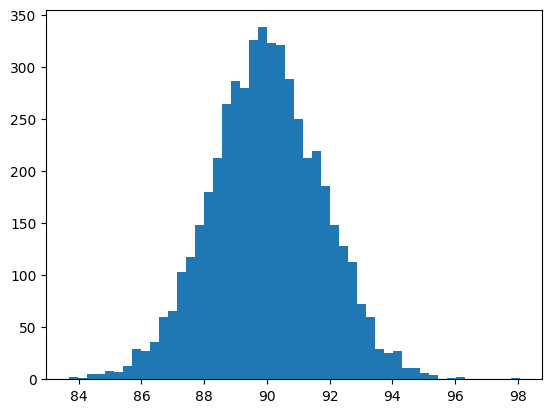

In [ ]:
raise NotImplementedError('Your code here')

### Задача 4

Реализуйте функцию, которая получает на вход два вектора $\mathbf{u}$ и $\mathbf{v}$.

Функция раскладывает вектор $\mathbf{v}$ в следующем виде: $\mathbf{v} = c\cdot\mathbf{u} + \mathbf{h}_v$, где $\mathbf{h}_v \perp \mathbf{u}$.

Функция выдает константу $c$ и вектор $\mathbf{h}_v$.

In [ ]:
def orthogonalize(u, v):
    dot_product = v @ u

    # Вычисляем квадрат нормы вектора u (скаляр)
    u_norm_squared = u @ u  # или np.linalg.norm(u) ** 2

    # Защита от деления на ноль (если u - нулевой вектор)
    if u_norm_squared == 0:
        # Если u нулевой, то любое разложение некорректно
        # Возвращаем c=0 и исходный вектор как перпендикулярную составляющую
        return 0.0, v.copy()

    # Вычисляем коэффициент c
    c = dot_product / u_norm_squared

    # Вычисляем перпендикулярную составляющую
    h_v = v - c * u

    return c, h_v

In [ ]:
# Do not change the tests!
# They are for your convenience.
u = np.array([1, 2, 3])
v = np.array([3, 4, 5])
c, h_v = orthogonalize(u, v)
np.testing.assert_almost_equal(
    actual=u @ h_v,
    desired=0.0,
    err_msg='Test 1: u and h_v are not orthogonal'
)
np.testing.assert_almost_equal(
    actual=c * u + h_v,
    desired=v,
    err_msg='Test 1: Decomposition is incorrect'
)
u = np.random.normal(size=100)
v = np.random.normal(size=100)
c, h_v = orthogonalize(u, v)
np.testing.assert_almost_equal(
    actual=u @ h_v,
    desired=0.0,
    err_msg='Test 2: u and h_v are not orthogonal'
)
np.testing.assert_almost_equal(
    actual=c * u + h_v,
    desired=v,
    err_msg='Test 2: Decomposition is incorrect'
)

### Задача 5

Напишите функцию, которая производит ортогонализацию столбцов матрицы методом Грама - Шмидта.

Для этого зафиксируйте первый вектор, а для каждого следующего вектора поочередно проведите ортогонализацию относительно уже обработанных.

Функция принимает на вход матрицу $A$, а возвращает копию матрицы $A$, в которой все столбцы ортогональны.

In [ ]:
# import numpy as np
# import scipy as sp

# def gram_schmidt_simple(A: np.array):

#     # Создаем копию матрицы, чтобы не изменять исходную
#     Q = A.copy().astype(float)

#     # Получаем количество столбцов
#     n_cols = Q.shape[1]

#     # Проходим по каждому столбцу, начиная со второго
#     for j in range(1, n_cols):
#         # Для текущего столбца j вычитаем проекции на все предыдущие столбцы
#         for i in range(j):
#             # Вычисляем проекцию столбца j на столбец i
#             dot_product = Q[:, j] @ Q[:, i]
#             norm_squared = Q[:, i] @ Q[:, i]

#             # Защита от деления на ноль
#             if norm_squared > 1e-10:
#                 # Вычитаем проекцию из текущего столбца
#                 projection = (dot_product / norm_squared) * Q[:, i]
#                 Q[:, j] -= projection

#     return Q  # ← ВОТ ЭТО БЫЛО ПРОПУЩЕНО!

In [ ]:
# def gram_schmidt_simple(A:np.array):

#   Q = A.copy().astype(float) #копия матрицы
#   n_cols = Q.shape[1] #количество столбцов

#   for j in range(1,n_cols): #проходим по каждому столбцу, начиная со 2
#     for i in range(j): # для текущего столбца j вычитаем проекции на все предыдущие столбцы
#       dot_product = Q[:,j] @ Q[:,i]
#       norm_squared = Q[:,i] @ Q[:,i]
#       if norm_squared > 1e-10:
#                          # Вычитаем проекцию из текущего столбца
#                projection = (dot_product / norm_squared) * Q[:, i]
#                Q[:, j] -= projection
#   return Q

In [ ]:
def gram_schmidt_simple(A:np.array):
  A_orth = np.zeros_like(A)
  A_orth[:,0] = A[:,0]
  for i in range(1, A.shape[1]):
    a=A[:,i]
    for j in range(0,i):
        _, a = orthogonalize(A_orth[:,j], a)
    A_orth[:,i] = a
  return A_orth

In [ ]:
# Do not change the tests!
# They are for your convenience.
A = np.random.normal(size=(5, 4))
A_orth = gram_schmidt_simple(A.copy())
np.testing.assert_almost_equal(
    actual=(A_orth.T @ A_orth)[~np.eye(A.shape[1], dtype=bool)],
    desired=np.zeros(A.shape[1] * (A.shape[1] - 1)),
    err_msg='Test 1, not all columns are orthogonal'
)
nullspace = sp.linalg.null_space(A.T)
np.testing.assert_almost_equal(
    actual=nullspace.T @ A_orth,
    desired=0.0,
    err_msg='Test 1, nullspace is not equal'
)

### Задача 6

Напишите функцию, проверяющую, принадлежит ли вектор $\mathbf{b}$ пространству столбцов матрицы $A$.

_Подсказка_: вам понадобятся функции из задач # 4 и 5.

In [ ]:
def is_in_image(A: np.ndarray, b: np.array) -> bool:
    raise NotImplementedError('Your code here')

In [ ]:
# Do not change the tests!
# They are for your convenience.
A = np.random.normal(size=(4, 2))
b_1 = A @ np.array([2, 3])
b_2 = np.random.normal(size=4)
np.testing.assert_equal(
    actual=is_in_image(A, b_1),
    desired=True,
    err_msg='Test 1, in-domain'
)
np.testing.assert_equal(
    actual=is_in_image(A, b_2),
    desired=False,
    err_msg='Test 1, out-of-domain'
)

### Задача 7

Известно, что для взятия обратной матрицы $A^{-1}$ матрица $A$ должна быть полноранговой.

А что если она будет _почти_ полноранговой?

Создайте случайную квадратную матрицу размера $20 \times 20$ ранга 1. Ее можно получить, взяв тензорное произведение двух случайных векторов: $A := \mathbf{a}\mathbf{b}^T$.

Создайте шумовую матрицу $X$ такого же размера.

Постройте график $c \sim \|I - (A + cX)(A + cX)^{-1}\|_F$, где
* $\|\cdot\|_F$ - норма Фробениуса: `np.linalg.matrix_norm(..., ord='fro')`
* $c$ - константа (сделайте перебор в логарифмической шкале от $10^{-10}$ до $10$)
* $I$ - единичная матрица.

In [ ]:
raise NotImplementedError('Your code here')